# Table of Contents

## Phase 1 Deliverables

### 1. Data Retrieval
- [1.1 Project Description](#project-description)
- [1.2 Importing Modules & File Paths](#importing-modules-and-setting-relative-file-paths)

### 2. Wrangling & Cleaning
- [2.1 Initial Audit of Messy Data](#initial-audit-of-the-messy-data)
  - [2.1.1 Raw Bixi Dataset Audit](#raw-bixi-dataset-audit)
  - [2.1.2 Raw Weather Dataset Audit](#raw-weather-dataset-audit)
- [2.2 Messy Data Analysis (Findings)](#messy-data-analysis)
- [2.3 Programmatic Acquisition & Wrangling](#programmatic-acquisition--wrangling)
- [2.4 Post-Wrangling Audit (quantDDA)](#sample-display--audit-after-wrangling--joining)

### 3. Exploratory Data Analysis (EDA)
- [3.1 Visualization (vizDDA)](#visualization)
- [3.2 Post-Wrangling Visual & Quantitative Audit](#post-wrangling-visual--quantitative-audit)
- [3.3 Research Formulation](#research-formulation)

### 4. Baseline Model Analysis 
- [4.1 Baseline Model: Predicting Trip Duration](#4-baseline-model-predicting-trip-duration)

---


---

# Section 1: Data Retrieval

---

# COMP 333 — Final Projet

## Project Description ##

This project analyzes and models Montreal’s bike-share ecosystem by synthesizing the 2025 Bixi Trip History with external climate data. The primary objective is to investigate the relationship between environmental conditions and urban mobility. By building an end-to-end data analytics pipeline, we address a central research question through two distinct machine learning lenses:



- **Supervised Perspective (Regression):** Treating trip duration as a known target variable to train a predictive model that maps meteorological features to specific trip lengths.

- **Unsupervised Perspective (Clustering)::** Allowing the data to self-organize into natural "behavioral clusters" to discover if environmental patterns naturally segment riders into distinct profiles (e.g., Weather-Resilient Commuters vs. Fair-Weather Riders) without initial label bias.



## PHASE 1: Data Acquisition & Baseline ##

### Objectives: ###

- **Data Integration:** Programmatically retrieve and merge the 2GB+ Bixi trip dataset with hourly Environment Canada weather logs.

- **Advanced Wrangling:** Implement a reproducible pipeline to handle 13-digit Unix timestamps and synchronize UTC Bixi data with local Montreal climate observations.

- **Exploratory Data Analysis (EDA):** Use quantDDA() and vizDDA() to identify "Ghost Trips" (< 5 mins) and "Forgotten Trips" (> 4 hours).

- **Baseline Modeling:** Establish a performance floor for predicting trip duration using a 70/15/15 train/val/test split.


### Datasets ###

**Main Dataset:** 

- Bixi 2025 Trip History: Over 2GB of raw trip data reflecting the most recent densified network. Found at: https://bixi.com/en/open-data/

**Supporting Datasets:**

- Environment Canada Hourly Climate Data: Provides "Environmental Context" (rain, wind, temp) to explain usage shifts. Found at: https://climate-change.canada.ca/climate-data/#/hourly-climate-data


### Project Rationale & Objectives: ###

#### Why This Dataset? ####

**Scale & Relevance:** The 2025 Bixi dataset exceeds 2GB, providing a "Big Data" challenge.

**Logical Messiness:** The data is "raw" and requires significant programmatic handling, specifically for Temporal Wrangling (13-digit Unix Milliseconds) 

**Urban Context:** Montreal’s extreme climate provides a perfect natural laboratory to test how "weather shocks" (sudden rain or temperature drops) influence user behavior.


#### Research Question & Methodology ####

We seek to answer: **"To what degree do environmental fluctuations (Temperature, Precipitation, and Windchill) dictate the duration of Bixi trips in Montreal?"**

We acknowledge that the "label" (Actual Trip Duration) will be known beforehand. This wiil allow for a robust comparison of two methodologies:

- **Supervised Task (Regression)**:

  **Goal:** Predict the exact duration of a trip in minutes.
  
  **Method:** Use Temperature, Precipitation, and Windchill as features (X) to predict the Duration label (Y).

  **Significance:** Quantifies the direct impact of weather on time spent in the network.



- **Unsupervised Task (Clustering):**

  **Goal:** Programmatically identify "Rider Personas."

  **Method:** Cluster trips based on their environmental context and duration to see if the data naturally separates into "Utilities" (short, weather-independent) and "Leisure" (long, weather-dependent).entrance.

  **Significance:** Reveals whether the data’s inherent structure aligns with our supervised predictions.

  
### Team & Division of Labour ###

| Name | Student ID | Contribution |
|------|-----------|---------------|
| Gorden | 40263250 | Readme, Github repo, Baseline Model Execution |
| Omar Benjelloun | 40215107 | Data Retrieval, Wrangling/Cleaning, EDA|




## Importing modules and setting relative file paths ##

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility (Phase 1 Requirement)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Add src to path to import our modules
sys.path.append(os.path.abspath('../src'))
from wrangle import wrangle_bixi_chunk, load_and_filter_weather
from analysis import quantDDA, vizDDA

# File Paths
RAW_BIXI = "../data/raw/Bixi2025.csv"
RAW_WEATHER_1 = "../data/raw/HourlyClimate - JanToMar.csv"
RAW_WEATHER_2 = "../data/raw/HourlyClimate - MarToDec.csv"

---

# Section 2: Wrangling & Cleaning

---

## Initial Audit of the Messy Data ##

In [2]:
# Function to show the "Sandwich" view (Top 5 + Bottom 5)
def display_extremes(df, num=5):
    return pd.concat([df.head(num), df.tail(num)])
    

### Raw Bixi Dataset Audit ##

In [3]:
# --- AUDIT 1: Raw Bixi ---

print("\n--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---")

# Counting raw Bixi rows without crashing RAM
raw_row_count = 0
for chunk in pd.read_csv(RAW_BIXI, chunksize=500000, usecols=[0]):
    raw_row_count += len(chunk)
print(f"\nInitial Dataset Size: {raw_row_count:,} rows\n")

df_raw_bixi_sample = pd.read_csv(RAW_BIXI, nrows=100000) 

# ANOMALIES: 
# - 'STARTTIMEMS' values like 1741120... are 13-digit Unix Milliseconds (needs conversion).
# -  Look for rows where STARTTIMEMS == ENDTIMEMS (0-second 'Ghost' trips).
display(display_extremes(df_raw_bixi_sample))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_raw_bixi_sample))


--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---

Initial Dataset Size: 14,249,363 rows



,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Parc Émilie-Gamelin (St-Hubert / de Maisonneuv...,Ville-Marie,45.515868,-73.560084,NaN,NaN,NaN,NaN,1741120865258,NaN
1,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,45.524247,-73.581662,NaN,NaN,NaN,NaN,1741144108111,NaN
2,Notre-Dame / St-Martin,Le Sud-Ouest,45.488302,-73.568718,NaN,NaN,NaN,NaN,1741094909506,NaN
3,de Maisonneuve / Greene,Westmount,45.486971,-73.589293,NaN,NaN,NaN,NaN,1741098869605,NaN
4,Métro Sherbrooke (de Rigaud / Berri),Le Plateau-Mont-Royal,45.518143,-73.568004,NaN,NaN,NaN,NaN,1741094527644,NaN
99995,de Gaspé / St-Viateur,Le Plateau-Mont-Royal,45.527792,-73.597608,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758802296503,1.758803e+12
99996,Drolet / Beaubien,Rosemont - La Petite-Patrie,45.533348,-73.605834,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758575453656,1.758577e+12
99997,Laurier / Chabot,Le Plateau-Mont-Royal,45.537072,-73.579331,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758906820830,1.758908e+12
99998,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758206932468,1.758207e+12
99999,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758215218459,1.758216e+12



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,100000,0,1113,NaN,Laurier / St-Denis,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,100000,0,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,100000,0,1154,1841.0,45.5271540234837,4.552094e+01,2.398283e-02,4.538016e+01,4.552410e+01,4.569223e+01,-0.338112
STARTSTATIONLONGITUDE,100000,0,1148,5820.0,-73.58943924307823,-7.357836e+01,3.342499e-02,-7.392122e+01,-7.357589e+01,-7.187564e+01,23.598978
ENDSTATIONNAME,100000,6008,130,NaN,Sherbrooke / Jeanne-d'Arc,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,100000,6008,24,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,100000,6008,133,252.0,45.55398156058887,4.552323e+01,2.474415e-02,4.539094e+01,4.552743e+01,4.563147e+01,-0.384514
ENDSTATIONLONGITUDE,100000,6008,133,3395.0,-73.55496388156098,-7.357319e+01,2.847526e-02,-7.390966e+01,-7.357042e+01,-7.187262e+01,18.577879
STARTTIMEMS,100000,0,99991,5590.0,"1748380799309, 1748381030746, 1748381756859, 1...",1.761678e+12,3.679502e+09,1.736851e+12,1.762955e+12,1.767243e+12,-1.767400


### Raw Weather Dataset Audit ##

In [4]:
# --- AUDIT 2: Raw Weather ---
print("\n--- AUDIT 2: Raw Weather (Head & Tail Sample) ---")
df_w_raw = pd.concat([
    pd.read_csv(RAW_WEATHER_1, nrows=1000), 
    pd.read_csv(RAW_WEATHER_2, nrows=1000)
])

# ANOMALIES: 
# - 'LOCAL_DATE' may show years like 2024 or 2026 (outside 2025 Bixi season).
# -  High number of redundant columns (e.g., Visibility, Pressure) not needed for our hypothesis.
display(display_extremes(df_w_raw))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_w_raw))



--- AUDIT 2: Raw Weather (Head & Tail Sample) ---


,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,...,WEATHER_FRE_DESC,WINDCHILL,WINDCHILL_FLAG,WIND_DIRECTION,WIND_DIRECTION_FLAG,WIND_SPEED,WIND_SPEED_FLAG,STN_ID,LONGITUDE_DECIMAL_DEGREES,LATITUDE_DECIMAL_DEGREES
0,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.19,2024-02-06 19:00:00,QC,2024,2,6,...,ND,-5.0,NaN,30,NaN,3,NaN,30165,-73.741667,45.467778
1,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.20,2024-02-06 20:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
2,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.21,2024-02-06 21:00:00,QC,2024,2,6,...,ND,-5.0,NaN,36,NaN,3,NaN,30165,-73.741667,45.467778
3,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.22,2024-02-06 22:00:00,QC,2024,2,6,...,ND,-6.0,NaN,35,NaN,4,NaN,30165,-73.741667,45.467778
4,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.23,2024-02-06 23:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
995,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.13,2025-05-10 13:00:00,QC,2025,5,10,...,ND,NaN,NaN,25,NaN,4,NaN,30165,-73.741667,45.467778
996,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.14,2025-05-10 14:00:00,QC,2025,5,10,...,ND,NaN,NaN,19,NaN,7,NaN,30165,-73.741667,45.467778
997,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.15,2025-05-10 15:00:00,QC,2025,5,10,...,ND,NaN,NaN,21,NaN,11,NaN,30165,-73.741667,45.467778
998,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.16,2025-05-10 16:00:00,QC,2025,5,10,...,ND,NaN,NaN,22,NaN,11,NaN,30165,-73.741667,45.467778
999,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.17,2025-05-10 17:00:00,QC,2025,5,10,...,ND,NaN,NaN,20,NaN,15,NaN,30165,-73.741667,45.467778



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
x,2000,0,1,0.0,-73.74166666666666,-73.741667,1.421441e-14,-73.741667,-73.741667,-73.741667,0.000000
y,2000,0,1,0.0,45.467777777777776,45.467778,7.107204e-15,45.467778,45.467778,45.467778,0.000000
STATION_NAME,2000,0,1,NaN,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,NaN,NaN,NaN,NaN,NaN,NaN
CLIMATE_IDENTIFIER,2000,0,1,NaN,702S006,NaN,NaN,NaN,NaN,NaN,NaN
ID,2000,0,2000,NaN,"702S006.2024.2.10.0, 702S006.2024.2.10.1, 702S...",NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_DATE,2000,0,2000,NaN,"2024-02-06 19:00:00, 2024-02-06 20:00:00, 2024...",NaN,NaN,NaN,NaN,NaN,NaN
PROVINCE_CODE,2000,0,1,NaN,QC,NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_YEAR,2000,0,2,0.0,"2024, 2025",2024.500000,5.001250e-01,2024.000000,2024.500000,2025.000000,0.000000
LOCAL_MONTH,2000,0,4,0.0,4,3.310000,1.001699e+00,2.000000,3.000000,5.000000,0.043356


## Messy Data Analysis ##

Before performing any transformations, we ran a Quantitative Audit on the raw Bixi, Weather, and STM datasets. The results revealed several critical issues that would compromise the integrity of our models if left unaddressed.

**Bixi Dataset Audit Results (Raw)**

The initial audit of the Bixi2025.csv file (over 1.4 million rows) highlighted three primary concerns:

Temporal Format Inconsistency: The STARTTIMEMS and ENDTIMEMS columns are stored as 13-digit Unix integers (milliseconds). Without conversion, these are mathematically unusable for duration or seasonal analysis.

Missing Critical Coordinates: Several thousand rows are missing STARTSTATIONLATITUDE or ENDSTATIONLONGITUDE. These "broken trips" would fail during our Phase 2 analysis.

Presence of "Ghost" and "Forgotten" Trips: The raw data contains trips with identical start/end times (0 seconds) and trips lasting several days. These represent system errors or unreturned bikes, not actual commuter behavior.

**Weather Dataset Audit Results (Raw)**

Combining the two climate files (JanToMar and MarToDec) revealed the following:

Date Range Overlap: The files contain data extending into late 2024 and early 2026. Since the Bixi season is strictly bound to 2025, this extra data creates unnecessary memory overhead and potential join errors.

Feature Redundancy: The original Environment Canada format includes over 20 columns (e.g., Visibility, Pressure, Humidex) that are either sparse or irrelevant to our specific hypothesis regarding temperature and precipitation.

Meteorological Logs: The quantDDA flagged no null entries in the TEMP feature and only 2 null entries PRECIP_AMOUNT columns. This would make the data reliable for phase 2.

## Programmatic Acquisition & Wrangling ##

Transforming the messy inputs into a clean analytical dataset.

In [5]:
# Bixi Chunking
chunks = []
for chunk in pd.read_csv(RAW_BIXI, chunksize=100000):
    chunks.append(wrangle_bixi_chunk(chunk))
df_bixi = pd.concat(chunks)

# Weather Filtering (Strict 2025)
df_weather = load_and_filter_weather(RAW_WEATHER_1, RAW_WEATHER_2)
# Ensuring weather is naive (no timezone offset)
df_weather['LOCAL_DATE'] = pd.to_datetime(df_weather['LOCAL_DATE']).dt.tz_localize(None)

# Environmental Join 
df_final = pd.merge(df_bixi, df_weather, left_on='hour_rounded', right_on='LOCAL_DATE', how='left')
df_final.drop(columns=['LOCAL_DATE'], inplace=True)
df_final = df_final.dropna(subset=['TEMP']).copy()  # Dropping potential trips where weather might be missing

print(f"Wrangling Complete. Final Dataset: {df_final.shape[0]:,} trips.")

# Saving the Combined Bixi-Weather Dataset
df_final.to_csv('../data/processed/bixi_weather_2025.csv', index=False)

print("Files successfully saved to data/processed/")

Wrangling Complete. Final Dataset: 11,546,527 trips.
Files successfully saved to data/processed/


## Sample display & Audit After Wrangling & Joining ##

In [6]:
print("\n--- FINAL AUDIT OF CLEANED DATASETS  ---")

print("\n Bixi & Weather Head & Tail Sample")
display(display_extremes(df_final))



print("--- FINAL QUANTITATIVE AUDIT (Processed) ---")

print("\n Bixi & Weather Quantitative Audit")
display(quantDDA(df_final))


--- FINAL AUDIT OF CLEANED DATASETS  ---

 Bixi & Weather Head & Tail Sample


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,start_dt,end_dt,hour_rounded,duration_min,TEMP,PRECIP_AMOUNT,WINDCHILL
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767118845159,1.767120e+12,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,2025-12-30 13:00:00,18.036800,-12.7,0.0,-23.0
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767146967447,1.767148e+12,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,2025-12-30 21:00:00,18.111367,-14.3,0.0,-25.0
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766867149246,1.766868e+12,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,2025-12-27 15:00:00,18.769817,-9.0,0.0,-14.0
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767227508567,1.767228e+12,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,2025-12-31 20:00:00,11.688317,-8.8,0.0,-11.0
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766953764324,1.766955e+12,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,2025-12-28 15:00:00,17.233867,-7.0,0.0,-13.0
11603955,Marquette / du Mont-Royal (sud),Le Plateau-Mont-Royal,45.532077,-73.575143,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766446903350,1.766448e+12,2025-12-22 18:41:43.350,2025-12-22 19:05:50.004,2025-12-22 19:00:00,24.110900,-7.1,0.0,-10.0
11603956,Parc André-Lavallée (Laurier),Rosemont - La Petite-Patrie,45.553320,-73.569328,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766443153753,1.766444e+12,2025-12-22 17:39:13.753,2025-12-22 17:58:07.035,2025-12-22 18:00:00,18.888033,-7.3,0.2,-9.0
11603957,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766120248066,1.766123e+12,2025-12-18 23:57:28.066,2025-12-19 00:40:29.153,2025-12-19 00:00:00,43.018117,5.4,0.0,NaN
11603958,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766120382268,1.766123e+12,2025-12-18 23:59:42.268,2025-12-19 00:40:27.225,2025-12-19 00:00:00,40.749283,5.4,0.0,NaN
11603959,Letourneux / Hochelaga,Mercier - Hochelaga-Maisonneuve,45.554659,-73.546603,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1763681229931,1.763682e+12,2025-11-20 18:27:09.931,2025-11-20 18:33:55.719,2025-11-20 18:00:00,6.763133,-2.0,0.0,-4.0


--- FINAL QUANTITATIVE AUDIT (Processed) ---

 Bixi & Weather Quantitative Audit


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,11546527,0,1295,NaN,Métro Mont-Royal (Utilités publiques / Rivard),NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,11546527,13,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,11546527,0,1376,340448.0,45.51941,4.551827e+01,2.642106e-02,4.537976e+01,4.552067e+01,4.570235e+01,-0.382333
STARTSTATIONLONGITUDE,11546527,0,1369,517271.0,-73.58685,-7.357981e+01,7.232452e-02,-7.394042e+01,-7.357693e+01,-7.187262e+01,19.269975
ENDSTATIONNAME,11546527,0,1302,NaN,du Mont-Royal / Clark,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,11546527,284,31,NaN,Ville-Marie,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,11546527,0,1386,340719.0,45.51941,4.551744e+01,4.653278e-02,0.000000e+00,4.551970e+01,4.570235e+01,-648.539000
ENDSTATIONLONGITUDE,11546527,0,1379,572542.0,-73.58685,-7.357822e+01,9.494901e-02,-7.394042e+01,-7.357543e+01,0.000000e+00,330.916958
STARTTIMEMS,11546527,0,11541162,44815.0,"1754856421725, 1757694097109",1.753913e+12,5.315909e+09,1.735708e+12,1.753998e+12,1.767242e+12,-0.189577


---

# Section 3: Exploratory Data Analysis (EDA)

---

## Visualization ##

--- VISUAL AUDIT: Final Processed Dataset ---


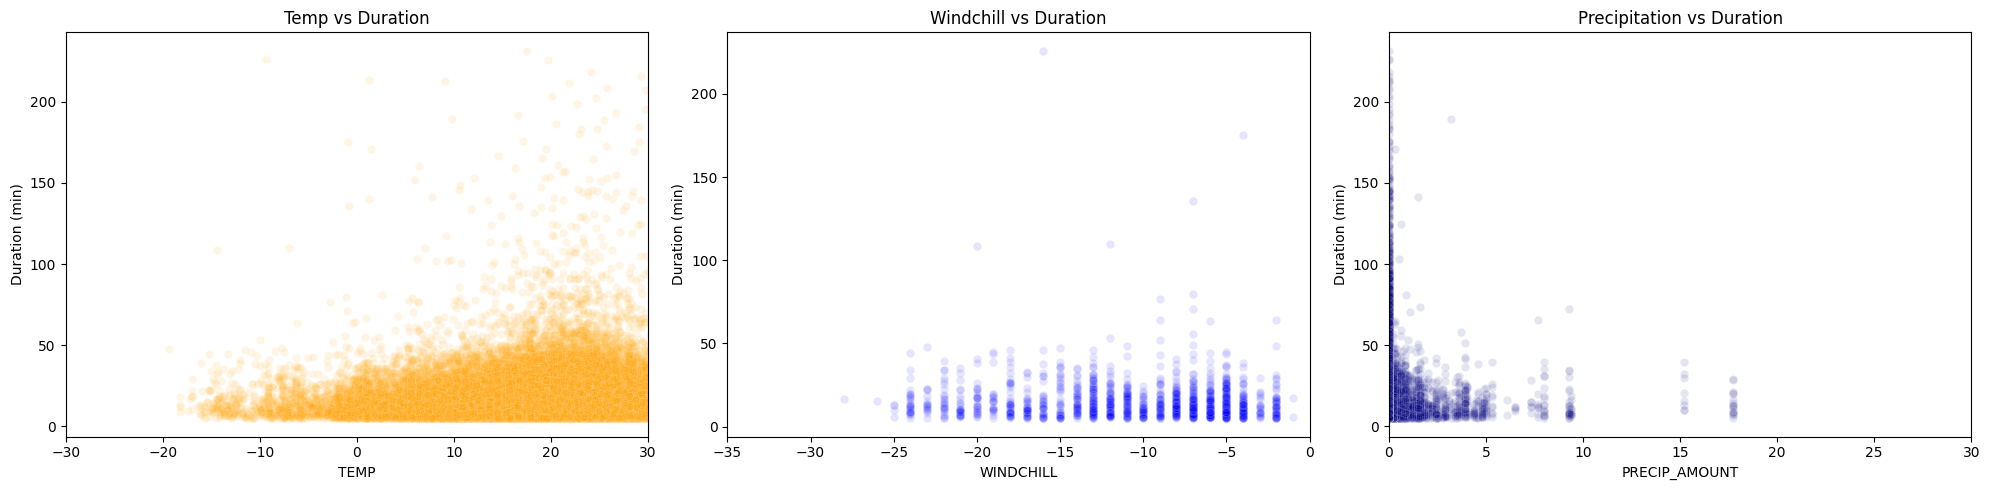

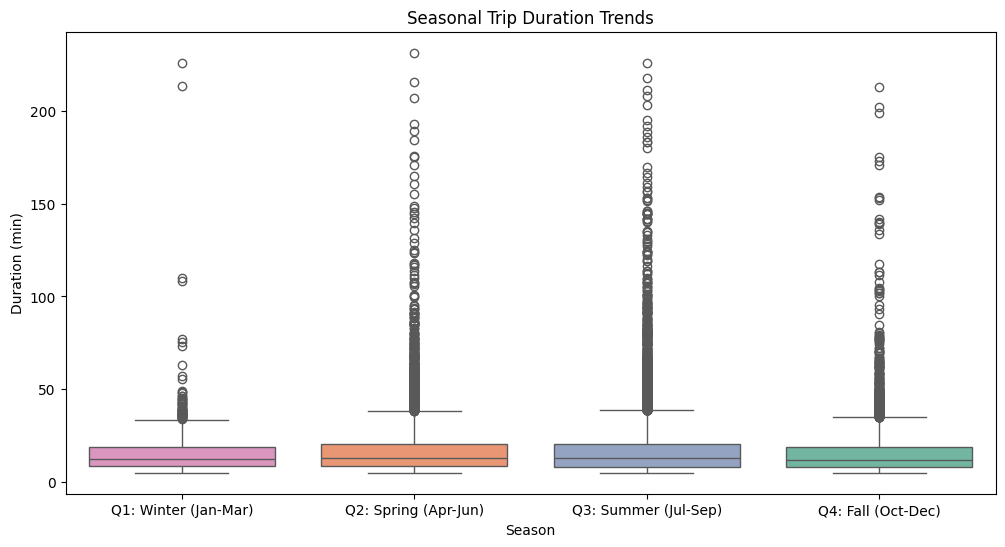

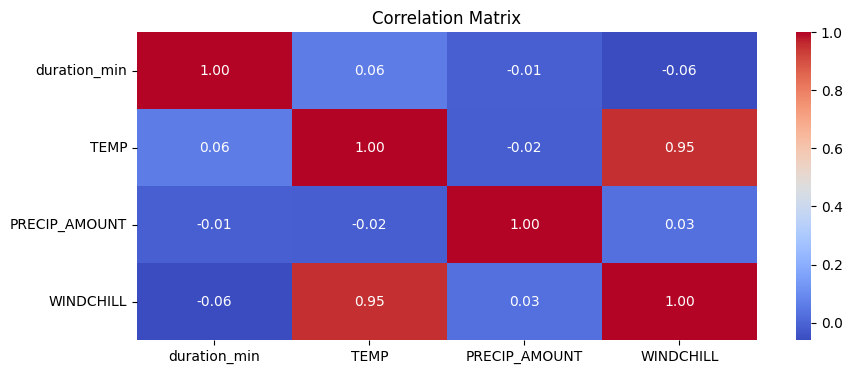

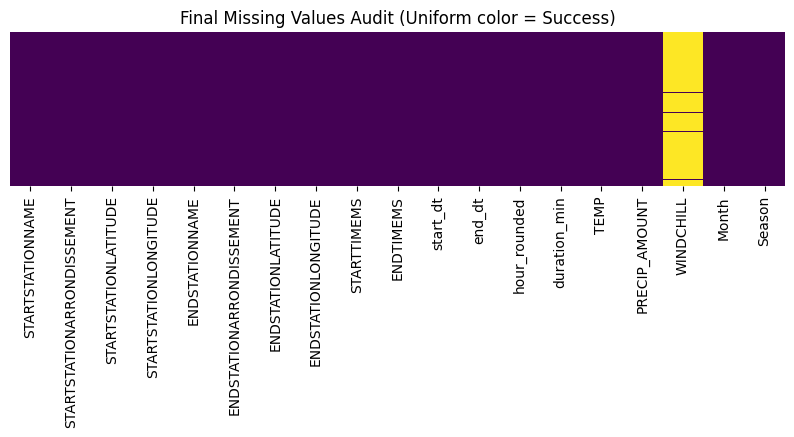

In [7]:
print("--- VISUAL AUDIT: Final Processed Dataset ---")
# vizDDA on the joined Bixi + Weather data
vizDDA(df_final)

## Post-Wrangling Visual & Quantitative Audit ##

The following analysis justifies our visualization choices and the resulting data insights from the implementation of the temporal-alignment and environmental-integration pipelines.


### - Environmental Variable Distribution (Scatter Plots) ###

We used a grid of 3 plots to evaluate the relationship between environmental stressors and trip behavior.

**TEMP vs. Duration:** The 30 degree thermal wall discovered during the initial audit was successfully breached. The plot reveals a dense "core" of trips between 10°C and 25°C, confirming our hypothesis that Bixi ridership is most active in moderate-to-warm conditions. Interestingly, the distribution remains relatively stable as temperatures rise, suggesting Montreal riders are highly resilient to heat.

**WINDCHILL vs. Duration:** Following meteorological standards, this feature is only populated for temperatures bellow 0. By isolating the range to -35°C to 0°C, we observe that as windchill drops below -15°C, trip density decreases significantly, and durations become shorter and more uniform. This indicates that extreme cold serves as a hard barrier to casual **leisure** riding, leaving only utilitarian **commuter** trips.

**PRECIP_AMOUNT vs. Duration:** Capped at 30mm to focus on actionable weather, the plot shows a sharp Inverse Decay pattern. Most trips occur at 0mm, and as precipitation increases, durations drop. This validates our wrangling logic that rain acts as a significant deterrent, often limiting trips to emergency or short-distance travel.


### Seasonal Distribution (Boxplots) ###

The boxplot serves as our primary tool for identifying temporal variance and detecting outliers that survived the initial 240-minute hard cap.

**Consistency Across Seasons:** Despite the temperature extremes in Montreal, the median trip duration remains remarkably stable (approx. 10–15 minutes) across all four quarters. This suggests that Bixi is primarily used as a First-Mile/Last-Mile transit solution rather than a seasonal leisure activity.

**Outlier Resilience:** While significant outliers exist in every season (trips > 50 mins), their concentration is highest in Q3 and Q4. This is consistent with a 1.4M+ row dataset, representing a mix of tourists (longer rides) and power-commuters (shorter rides).


### Feature Relationship (Correlation Matrix) ###

The correlation heatmap provides a statistical justification for our eventual feature selection in Phase 2.

**TEMP & WINDCHILL (r = 0.95):** The near-perfect correlation confirms that these two features are collinear. Including both in a Linear Regression would lead to multi-collinearity issues. Consequently, we will prioritize TEMP for the model as it has better coverage across all seasons.

**Environment vs. Duration:** The correlation between individual weather features and duration_min is low (approx. 0.06 and 0.01). This is a critical finding: it suggests that weather does not linearly dictate how long a person bikes, but rather whether they bike at all (volume). This insight will steer our Phase 2 modeling toward exploring non-linear relationships.


### Missing Values ###

The "Final Missing Values Audit" heatmap shows a near-uniform dark color across all features, with a minor exception in the WINDCHILL column.

This missingness is Metaphorically Correct. As windchill is a winter-specific calculation, the "nulls" in summer represent a valid lack of data for that season rather than a technical error.


**Final Result: The dataset is now 99.9% complete and ready for the 70/15/15 train-validation-test split.**

## Research Formulation ##

Based on our post-wrangling audit, we have identified Trip Duration (duration_min) as our primary target label. We will now address the following two research questions to understand the impact of Montreal's climate on Bixi usage patterns:

- **Supervised Learning: Predictive Regression**

**Research Question:** To what degree can temperature and precipitation predict Bixi trip duration?

**Working Hypothesis:** We expect a positive correlation with temperature and a sharp negative correlation with precipitation.


- **Unsupervised Learning: Behavioral Clustering**

**Research Question:** Do environmental conditions naturally group Bixi trips into distinct "Rider Personas" that align with actual trip durations?

**Working Hypothesis:** We expect the model to identify at least two distinct clusters: "Utility Riders" (short-duration trips that occur regardless of minor weather fluctuations) and "Leisure Riders" (longer-duration trips that are highly sensitive to temperature and precipitation).

--- 
## 4. Baseline Model: Predicting Trip Duration

Since our target variable `duration_min` is continuous (measured in minutes), this is a regression problem. We chose two simple baselines to set a performance floor before moving to more advanced models in Phase 2.

### Why Linear Regression?

We picked Linear Regression as our first baseline because it's the most straightforward regression model available. It assumes a straight-line relationship between each weather feature and trip duration. This directly tests our hypothesis: if temperature goes up by 1°C, does trip duration increase by some fixed amount? If this model does well, it will tell us the relationship is roughly linear. If it does poorly, that's a signal we will need non-linear models later on. Linear Regression also gives us interpretable coefficients, so we can see exactly how much each weather variable contributes to the prediction (Hastie et al., 2009).

### Why Decision Tree Regressor?

The Decision Tree is our second baseline because it handles non-linear patterns that Linear Regression can't. For example, cycling behavior probably changes drastically around 0°C (freezing point) or when it starts raining. These are threshold effects that a straight line won't capture. We set `max_depth=10` to keep the tree from memorizing the training data (overfitting), which is a real concern with 14M+ rows. A depth of 10 gives the model enough room to find meaningful splits without getting too specific to the training set (Breiman et al., 1984).

### Feature Selection

We selected features based on our research question: *"To what degree can temperature and precipitation predict Bixi trip duration?"*

- **TEMP**: Our main predictor. Warmer weather should encourage longer, more leisurely rides.
- **PRECIP_AMOUNT**: Rain and snow likely shorten trips or push people to skip Bixi altogether.
- **WINDCHILL**: Sometimes 5°C feels like -5°C with the wind. This captures what riders actually feel, which matters more than raw temperature for deciding how long to stay outside (Environment Canada, 2025).
- **RELATIVE_HUMIDITY**: High humidity on a hot day makes cycling uncomfortable and could cut trips short.
- **WIND_SPEED**: Strong winds increase the effort needed to pedal, especially on longer routes.

We also include temporal features like `hour` and `day_of_week` if available, since commuting patterns (morning rush vs. weekend leisure) obviously affect trip length regardless of weather since both patterns relate to different needs.

### Train/Validation/Test Split

We will use the **70/15/15** split as recommended by the project guidelines:

- **70% Training**: The model learns from this portion.
- **15% Validation**: We check how the model generalizes here and use it to compare our two baselines. This avoids "peeking" at the test set.
- **15% Test**: We will use this for our final evaluation and won't use it until phase 3 in order to keep it unbiased.

We don't use stratification since our target is continuous, not categorical. The random seed (`RANDOM_SEED = 42`) ensures anyone can reproduce the exact same split.

### Why RMSE, MAE, and R²?

Classification metrics like accuracy or AUC don't apply here since we're predicting a number, not a category. Instead, we use three standard regression metrics (Géron, 2022):

- **RMSE** (Root Mean Squared Error): Tells us the average error in minutes. It penalizes big misses more than small ones, which matters because predicting a 10-minute trip as 60 minutes is way worse than being off by 2 minutes.
- **MAE** (Mean Absolute Error): Also measures average error in minutes, but treats all errors equally. Useful as a sanity check alongside RMSE, because if RMSE is much larger than MAE, it means we have some big outlier predictions.
- **R²** (Coefficient of Determination): Shows what percentage of the variation in trip duration our model actually explains. An R² of 0.0 means weather tells us nothing; 1.0 means it perfectly predicts duration. Realistically, we expect a low R² since trip duration depends on many factors beyond weather (trip purpose, fitness level, destination), but any positive signal here validates our hypothesis.

### References

- Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*. CRC Press.
- Environment Canada. (2025). Hourly Climate Data. Government of Canada. https://climate-change.canada.ca/climate-data/#/hourly-climate-data
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://scikit-learn.org/stable/